# DES 2018 reproduced: the matched-filter map, its background, its residuals

Shipp et al. (2018, [arXiv:1801.03097](https://arxiv.org/abs/1801.03097)) found
their streams by eye, in maps of matched-filter star counts with a smooth
background subtracted. This notebook redoes that analysis on our DES Y6 Gold
download, at the distance modulus of the paper's Figures 3 and 4, m−M = 16.7:

1. the matched-filter density over the whole footprint, unmasked (their Fig. 3, top);
2. a 5th-order 2D polynomial background, fitted with `streamgoggles.data_preparation`
   over the sky left after masking Sagittarius, the LMC, the Galactic disk and every
   catalogued globular cluster, dwarf and Local Group galaxy;
3. their Fig. 4: the residuals, and the background with the streams drawn on it.

It then swaps in our selection, to answer the question it was written for:
**when a DES 2018 stream is missing from our results, is it missing from the
data, or did our cuts and filter lose it?** Everything is greyscale, as in the paper.

**What follows the paper, and what cannot.**

| | DES 2018 (Shipp et al. 2018) | here |
|---|---|---|
| data | Y3A2 Gold; stars from ngmix sizes; PSF magnitudes, SFD extinction ($R_g$ = 3.185) | Y6 Gold; stars are `0 <= EXT_XGB <= 1`; PSF magnitudes, SFD extinction ($R_g$ = 3.186) |
| sample | 16 < g < 23.5 and 0 < g−r < 1 | the same |
| isochrone | Dotter et al. (2008), 13 Gyr, Z = 0.0002 | Marigo et al. (2017), 13 Gyr, Z = 0.0002 — see §2 |
| filter | E = 2, C = (0.05, 0.10), Δμ = 0.5, err(g) = 0.001 + exp((g − 27.09)/1.09) | the same, built by streamobs |
| maps | HEALPix nside 512, Gaussian smoothing σ = 0.3° | the same |
| footprint | griz detection fraction > 50% | g and r star coverage > 50% (§1) |
| background | 2D polynomial of 5th order, polar Lambert equal-area projection | the same, with `polyfit2d` (degree 5 in each coordinate) |
| mask | Sagittarius, the LMC, the Galactic disk (extents not given); r < 1° around bright globular clusters, satellite and Local Group galaxies | Sagittarius to 9° from its track, the LMC to 20°, the disk at b > −35° towards the inner Galaxy; 1° around every catalogued globular cluster, dwarf and Local Group galaxy (§4) |

The data difference cannot be undone: a different release, depth and
star/galaxy classifier. Everything else is matched as closely as the tools allow.

In [1]:
import warnings
from pathlib import Path

import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import patheffects
from numpy.polynomial import polynomial
from scipy.ndimage import gaussian_filter
from streamobs.match_filter import default_errors_des2018

from streamgoggles.data_preparation import polyfit2d, process_data_polyfit2d
from streamgoggles.evaluation.footprint import track_band
from streamgoggles.matched_filter import DES_YR6_ERROR_MODEL, StreamobsSplineFilter
from streamgoggles.objects_overlap import (
    DES2018_DISTANCE_MODULI,
    DES2018_ENDPOINTS,
    DES2018_STREAM_WIDTHS,
    DES2018_TRACKS,
    des2018_arc,
    get_dwarf,
    get_GC,
    stream_tracks,
)

warnings.filterwarnings("ignore")  # ugali and healpy are chatty

DATA = Path("~/Documents/data/DES_yr6").expanduser()  # the strips fetched by scripts/fetch_des_dr2.py
DM = 16.7           # distance modulus of the paper's Figs. 3 and 4
NSIDE = 512         # the paper's pixels, 0.013 deg2
SIGMA = 0.3         # deg, the paper's Gaussian smoothing
NPIX = hp.nside2npix(NSIDE)
TO_GALACTIC = hp.Rotator(coord=["C", "G"])

## 1. The stars, and where the survey is

The download already holds only Gold stars (`0 <= EXT_XGB <= 1`, footprint
and foreground flags applied, extinction-corrected PSF magnitudes, 15.5 to 25
in g and r, signal-to-noise above 2): see `manifest.json` beside the data, and
`notebooks/real_des_data.ipynb`. The maps are made in Galactic coordinates,
the frame the paper fits and draws in.

In [2]:
columns = ["ra", "dec", "g", "r", "g_err", "r_err"]
frames = [pd.read_parquet(p, columns=columns) for p in sorted(DATA.glob("des_y6gold_dec*.parquet"))]
stars = pd.concat([f for f in frames if len(f)], ignore_index=True)  # empty strips lie outside the survey
stars = stars.rename(columns={"g": "des_yr6_g_obs", "r": "des_yr6_r_obs"})  # what the filters read
l, b = TO_GALACTIC(stars["ra"].to_numpy(), stars["dec"].to_numpy(), lonlat=True)
pix = hp.ang2pix(NSIDE, l, b, lonlat=True)
print(f"{len(stars):,} stars")

49,068,865 stars


**Pixels outside the footprint, and on its edge, must not reach the fit.**
A count map is zero outside the survey and too low on its edge; either would
drag the polynomial down. The paper keeps pixels whose griz detection fraction
is above 50%. The equivalent here is built from the stars themselves: the
fraction of each pixel's four nside-1024 sub-pixels that hold at least one
star. Sub-pixels hold dozens of stars even in the sparsest sky (printed
below), so an empty one is outside the survey or in a Gold foreground hole,
not a fluctuation. Counts are divided by that fraction; pixels below one half
are outside the footprint and are NaN from here on.

In [3]:
fine = np.bincount(hp.ang2pix(2 * NSIDE, l, b, lonlat=True), minlength=hp.nside2npix(2 * NSIDE))
print(f"stars per occupied nside-1024 sub-pixel: 1st percentile {np.percentile(fine[fine > 0], 1):.0f}, "
      f"median {np.median(fine[fine > 0]):.0f}")
coverage = hp.ud_grade((fine > 0).astype(float), NSIDE)  # 0, 0.25, 0.5, 0.75 or 1
footprint = coverage >= 0.5
AREA = hp.nside2pixarea(NSIDE, degrees=True)
print(f"footprint: {footprint.sum() * AREA:,.0f} deg2, {(coverage[footprint] < 1).mean():.1%} of it "
      f"in partly covered pixels (the paper: 4,946 deg2 of Y3)")

stars per occupied nside-1024 sub-pixel: 1st percentile 5, median 27


footprint: 5,002 deg2, 2.3% of it in partly covered pixels (the paper: 4,946 deg2 of Y3)


## 2. Two selections: DES 2018's and ours

Each selection is a set of **cuts** and a **matched filter**. Crossing the two
gives four selections, which separate what the cuts do from what the filter
does:

- **DES 2018 cuts**: 16 < g < 23.5 and 0 < g−r < 1 (the paper's Sec. II).
- **our cuts**: 16 to 24.5 in g and r, signal-to-noise above 5 in both
  (`scripts/real_data/background.py`) — the sample our models are trained and
  run on. A magnitude deeper.
- **DES 2018 filter**: the paper's Eq. 4 with its parameters and its error
  model (streamobs's `default_errors_des2018`), including its red colour
  padding of 0.10, where streamobs's default is 0.05.
- **our filter**: the DES Y6 error model at one sigma
  (`docs/source/experiments/matched_filter_errors.md`).

Both filters stop at the turnoff, as the paper's does (its Fig. 2).

In [4]:
g, r = stars["des_yr6_g_obs"], stars["des_yr6_r_obs"]
MAX_ERR = 1.0857 / 5  # signal-to-noise 5
CUTS = {
    "DES 2018": ((g > 16) & (g < 23.5) & (g - r > 0) & (g - r < 1)).to_numpy(),
    "ours": (g.between(16, 24.5) & r.between(16, 24.5)
             & (stars["g_err"] < MAX_ERR) & (stars["r_err"] < MAX_ERR)).to_numpy(),
}
ISOCHRONE = {"age": 13.0, "z": 0.0002}
FILTERS = {
    "DES 2018": StreamobsSplineFilter({**ISOCHRONE, "color_spread": [0.05, 0.10]}, "des_yr6",
                                      error_model=default_errors_des2018),
    "ours": StreamobsSplineFilter({**ISOCHRONE, "error_multiplier": [1.0, 1.0]}, "des_yr6",
                                  error_model=DES_YR6_ERROR_MODEL),
}
SELECTIONS = {  # name: (cuts, filter)
    "DES 2018": ("DES 2018", "DES 2018"),
    "DES 2018 cuts, our filter": ("DES 2018", "ours"),
    "our cuts, DES 2018 filter": ("ours", "DES 2018"),
    "ours": ("ours", "ours"),
}
mags = stars[["des_yr6_g_obs", "des_yr6_r_obs"]]


def select(name, dm, rows=None):
    """Indices of the stars selection `name` keeps at distance modulus dm, among `rows` if given."""
    cuts, flt = SELECTIONS[name]
    keep = CUTS[cuts] if rows is None else CUTS[cuts] & rows
    index = np.flatnonzero(keep)
    return index[FILTERS[flt].select(mags.iloc[index], ["g", "r"], dm)]


for name, keep in CUTS.items():
    print(f"{name} cuts keep {keep.sum():,} stars ({keep.mean():.0%})")

DES 2018 cuts keep 12,677,863 stars (26%)
ours cuts keep 40,111,394 stars (82%)


**The isochrone.** The paper's is Dotter et al. (2008). ugali has it here
only at 10 and 12 Gyr — and silently returns the 12 Gyr file when asked for
13 — so both filters use Marigo et al. (2017) at the paper's 13 Gyr and
Z = 0.0002. How much the library matters, on the DES 2018 sample at m−M = 16.7:

In [5]:
dotter = StreamobsSplineFilter({"age": 12.0, "z": 0.0002, "isochrone_model": "Dotter2008",
                                "color_spread": [0.05, 0.10]}, "des_yr6", error_model=default_errors_des2018)
sample = mags[CUTS["DES 2018"]]
marigo_keeps = FILTERS["DES 2018"].select(sample, ["g", "r"], DM)
dotter_keeps = dotter.select(sample, ["g", "r"], DM)
print(f"Marigo 2017, 13 Gyr: {marigo_keeps.sum():,} stars; Dotter 2008, 12 Gyr: {dotter_keeps.sum():,}; "
      f"in common: {(marigo_keeps & dotter_keeps).sum() / (marigo_keeps | dotter_keeps).sum():.0%} of either")

Marigo 2017, 13 Gyr: 2,835,033 stars; Dotter 2008, 12 Gyr: 2,761,068; in common: 85% of either


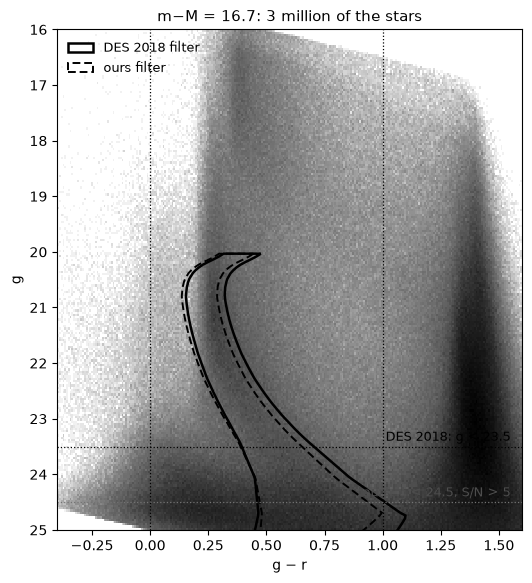

In [6]:
fig, ax = plt.subplots(figsize=(6, 6.5))
subsample = np.random.default_rng(0).choice(len(stars), 3_000_000, replace=False)
ax.hist2d((g - r).to_numpy()[subsample], g.to_numpy()[subsample], bins=(260, 220),
          range=((-0.4, 1.6), (16, 25)), cmap="Greys", norm="log")
for name, style in (("DES 2018", dict(color="black", lw=1.8)),
                    ("ours", dict(color="black", lw=1.4, ls=(0, (4, 2))))):
    polygon = FILTERS[name]._polygon(["g", "r"], DM)  # (colour, g) vertices
    ax.fill(polygon[:, 0], polygon[:, 1], fill=False, label=f"{name} filter", **style)
ax.axhline(23.5, color="black", lw=0.9, ls=":")
ax.axhline(24.5, color="0.45", lw=0.9, ls=":")
for colour in (0, 1):
    ax.axvline(colour, color="black", lw=0.9, ls=":")
ax.text(1.55, 23.45, "DES 2018: g < 23.5", ha="right", va="bottom", fontsize=9)
ax.text(1.55, 24.45, "ours: g < 24.5, S/N > 5", ha="right", va="bottom", fontsize=9, color="0.3")
ax.set_xlim(-0.4, 1.6); ax.set_ylim(25, 16)
ax.set_xlabel("g − r"); ax.set_ylabel("g")
ax.set_title(f"m−M = {DM}: 3 million of the stars", fontsize=11)
ax.legend(loc="upper left", frameon=False, fontsize=9)
plt.show()

Dotted lines are the DES 2018 cuts (0 < g−r < 1 and g < 23.5) and our faint
limit. The two filters differ little in width: the DES 2018 filter is twice
DES 2018's small errors, ours one of the larger Y6 errors. **What differs is
depth**: our sample runs a magnitude past 23.5, where the filter is widest and
the star/galaxy confusion worst.

## 3. The matched-filter map at m−M = 16.7, unmasked

Stars per HEALPix pixel, corrected for coverage, smoothed with a σ = 0.3°
Gaussian — the paper's Fig. 3 (top), on the paper's colour scale. The
smoothing uses footprint pixels only, so the survey edge is not blurred into
the empty sky around it.

In [7]:
counts = {name: np.bincount(pix[select(name, DM)], minlength=NPIX).astype(float) for name in SELECTIONS}
density = {name: np.where(footprint, c / np.maximum(coverage, 0.5), np.nan) for name, c in counts.items()}
for name, c in counts.items():
    print(f"{name:26s} {c.sum():>10,.0f} stars, {np.nanmean(density[name]):.1f} per pixel")

WEIGHT = hp.smoothing(footprint.astype(float), sigma=np.radians(SIGMA))


def smooth(m):
    """Gaussian smoothing over footprint pixels only: outside pixels neither contribute nor get a value."""
    value = hp.smoothing(np.where(footprint, m, 0.0), sigma=np.radians(SIGMA))
    return np.where(footprint, value / WEIGHT, np.nan)


smoothed = {name: smooth(m) for name, m in density.items()}

DES 2018                    2,835,033 stars, 7.5 per pixel
DES 2018 cuts, our filter   2,360,644 stars, 6.2 per pixel
our cuts, DES 2018 filter   5,260,585 stars, 13.8 per pixel
ours                        4,467,716 stars, 11.8 per pixel


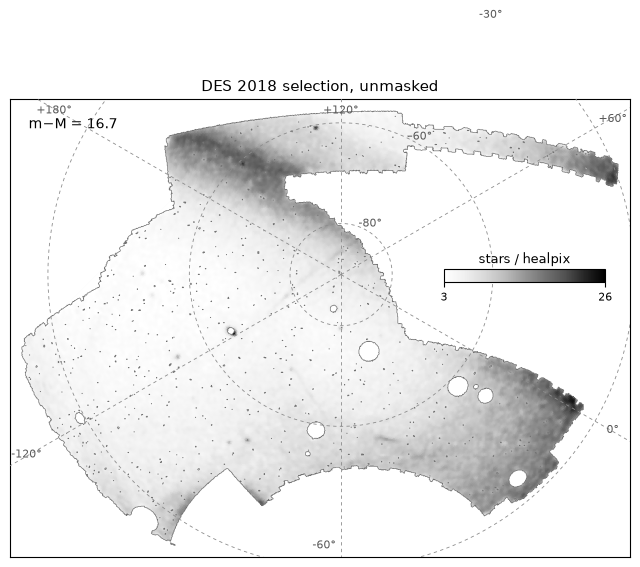

In [8]:
PROJECTION = hp.projector.AzimuthalProj(rot=(120, -90), lamb=True, xsize=1600, reso=5.5)
EXTENT = PROJECTION.get_extent()
GREYS = plt.get_cmap("Greys").copy()
GREYS.set_bad("white")


def to_image(m):
    """A HEALPix map, projected: polar Lambert equal-area on the south Galactic pole, l = 120 up."""
    image = PROJECTION.projmap(np.asarray(m, dtype=float), lambda x, y, z: hp.vec2pix(NSIDE, x, y, z))
    return np.where(np.isfinite(image), image, np.nan)


x_fp, y_fp = PROJECTION.ang2xy(*hp.pix2ang(NSIDE, np.flatnonzero(footprint), lonlat=True), lonlat=True)
XLIM, YLIM = (x_fp.min() - 0.04, x_fp.max() + 0.04), (y_fp.min() - 0.04, y_fp.max() + 0.04)
FOOTPRINT_IMAGE = np.nan_to_num(to_image(footprint.astype(float)))


def graticule(ax):
    """Dashed parallels at b = -80, -60, -30 and meridians every 60 degrees, as in the paper."""
    style = dict(color="0.55", lw=0.6, ls=(0, (4, 4)), zorder=3)
    lon = np.linspace(0, 360, 721)
    for lat in (-80, -60, -30):
        ax.plot(*PROJECTION.ang2xy(lon, np.full_like(lon, lat), lonlat=True), **style)
        x, y = PROJECTION.ang2xy(90.0, lat + 1.5, lonlat=True)
        ax.text(x, y, f"{lat}°", fontsize=8, color="0.35", ha="center", va="center", zorder=5)
    lat = np.linspace(-90, 0, 721)
    for lon0 in range(0, 360, 60):
        x, y = PROJECTION.ang2xy(np.full_like(lat, lon0), lat, lonlat=True)
        ax.plot(x, y, **style)
        inside = np.flatnonzero((x > XLIM[0]) & (x < XLIM[1]) & (y > YLIM[0]) & (y < YLIM[1]))
        i = inside[-1]
        ax.annotate(f"{lon0 if lon0 <= 180 else lon0 - 360:+d}°".replace("+0°", "0°"), (x[i], y[i]),
                    xytext=(-12 * np.sign(x[i]), -8 * np.sign(y[i])), textcoords="offset points",
                    fontsize=8, color="0.35", ha="center", va="center", zorder=5)


def sky(ax, m, vmin, vmax, label, text=f"m−M = {DM}"):
    """One map panel: greyscale, NaN white, footprint outlined, graticule, colour bar inset."""
    im = ax.imshow(to_image(m), extent=EXTENT, origin="lower", cmap=GREYS, vmin=vmin, vmax=vmax,
                   interpolation="nearest")
    ax.contour(FOOTPRINT_IMAGE, levels=[0.5], extent=EXTENT, origin="lower", colors="0.45", linewidths=0.5)
    graticule(ax)
    ax.set_xlim(XLIM); ax.set_ylim(YLIM); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    if text:
        ax.text(0.03, 0.96, text, transform=ax.transAxes, fontsize=10, va="top")
    cax = ax.inset_axes([0.70, 0.60, 0.26, 0.03])
    bar = plt.colorbar(im, cax=cax, orientation="horizontal", ticks=[vmin, vmax])
    bar.set_label(label, fontsize=9)
    bar.ax.xaxis.set_label_position("top")
    bar.ax.tick_params(labelsize=8)
    return im


fig, ax = plt.subplots(figsize=(8, 6.4))
sky(ax, smoothed["DES 2018"], 3.0, 26.0, "stars / healpix")
ax.set_title("DES 2018 selection, unmasked", fontsize=11)
plt.show()

The dark regions are the ones the paper names in its Fig. 3: the LMC (lower
left), Sagittarius (top: the neck joining the northern strip to the main
footprint) and the Galactic thick disk (lower right). The small white discs
are Gold's foreground holes around bright stars and galaxies.

## 4. The mask

The paper masks Sagittarius, the LMC and the Galactic disk without giving
their extents, and "small regions (r < 1°)" around bright globular clusters,
satellite galaxies and Local Group galaxies. Here:

- **Sagittarius**: every pixel within 9° of any of its galstreams tracks — how
  far its stars reach in our real-data maps (`docs/source/experiments/real_des.md`);
- **the LMC**: 20° around its centre, for the same reason;
- **the Galactic disk**: b > −35° within 60° of the Galactic centre, where
  this map rises to three times its high-latitude density; the anticentre side
  reaches b = −21° with no such rise, and is kept;
- **1° around every catalogued globular cluster (Harris) and dwarf or Local
  Group galaxy** (`dwarf_all.csv`) whose centre lies within 1° of the footprint.
  The SMC's centre is 3° beyond the footprint, so no disc reaches it.

In [9]:
def discs(ra, dec, radius):
    """Pixels within `radius` degrees of any of the given equatorial positions."""
    lon, lat = (np.atleast_1d(v) for v in TO_GALACTIC(np.atleast_1d(ra), np.atleast_1d(dec), lonlat=True))
    out = np.zeros(NPIX, bool)
    for lo, la in zip(lon, lat):
        out[hp.query_disc(NSIDE, hp.ang2vec(lo, la, lonlat=True), np.radians(radius), inclusive=True)] = True
    return out


sagittarius = np.zeros(NPIX, bool)
for ra, dec in stream_tracks("Sagittarius", tracks={}).values():
    step = max(1, len(ra) // 720)  # points every half degree or closer, well inside 9
    sagittarius |= discs(ra[::step], dec[::step], 9.0)
lon, lat = hp.pix2ang(NSIDE, np.arange(NPIX), lonlat=True)
catalogued = pd.concat([pd.DataFrame({"ra": np.asarray(t["ra"], float), "dec": np.asarray(t["dec"], float)})
                        for t in (get_GC(), get_dwarf())], ignore_index=True)
near = [bool(footprint[hp.query_disc(NSIDE, v, np.radians(1.0), inclusive=True)].any())
        for v in hp.ang2vec(*TO_GALACTIC(catalogued["ra"].to_numpy(), catalogued["dec"].to_numpy(), lonlat=True),
                            lonlat=True)]
MASK_PARTS = {
    "Sagittarius, 9° from its track": sagittarius,
    "LMC, 20°": discs(80.894, -69.756, 20.0),
    "Galactic disk, b > −35° towards the centre": (lat > -35) & ((lon < 60) | (lon > 300)),
    f"{sum(near)} clusters and galaxies, 1°": discs(catalogued["ra"][near], catalogued["dec"][near], 1.0),
}
masked = np.logical_or.reduce(list(MASK_PARTS.values()))
fitted = footprint & ~masked
for part, where in MASK_PARTS.items():
    print(f"{part:44s} {(where & footprint).sum() * AREA:6,.0f} deg2")
print(f"{'fitted':44s} {fitted.sum() * AREA:6,.0f} deg2 of {footprint.sum() * AREA:,.0f}")

Sagittarius, 9° from its track                  531 deg2
LMC, 20°                                        291 deg2
Galactic disk, b > −35° towards the centre       84 deg2
63 clusters and galaxies, 1°                    180 deg2
fitted                                        3,957 deg2 of 5,002


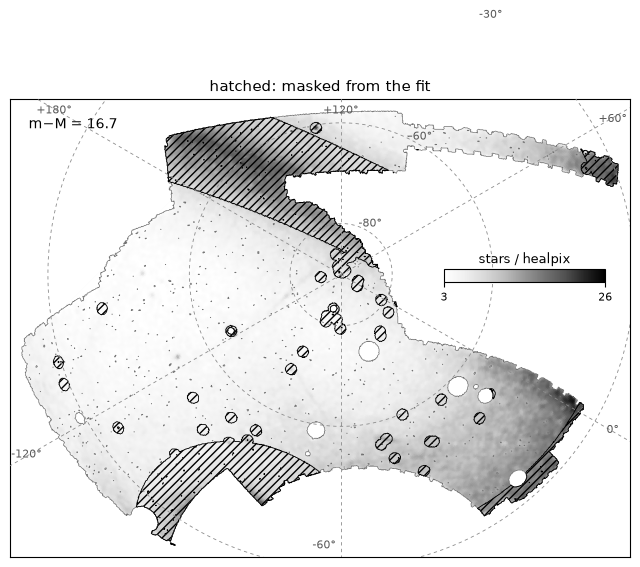

In [10]:
fig, ax = plt.subplots(figsize=(8, 6.4))
sky(ax, smoothed["DES 2018"], 3.0, 26.0, "stars / healpix")
ax.contourf(np.nan_to_num(to_image(masked & footprint)), levels=[0.5, 1.5], extent=EXTENT, origin="lower",
            colors="none", hatches=["////"])
ax.contour(np.nan_to_num(to_image(masked & footprint)), levels=[0.5], extent=EXTENT, origin="lower",
           colors="black", linewidths=0.6)
ax.set_title("hatched: masked from the fit", fontsize=11)
plt.show()

## 5. The background fit

`process_data_polyfit2d` projects every pixel into the polar Lambert plane,
keeps those not masked, and scales both coordinates to [−1, 1];
`polyfit2d(..., [5, 5])` fits the polynomial by least squares (degree up to 5
in each coordinate: 36 terms), and `polyval2d` evaluates it everywhere.

Three things keep NaN values and empty sky out of the fit:

- **the fit mask includes everything outside the footprint** (`mask=~fitted`),
  not only the objects: outside pixels hold zero stars, not a low density;
- **the map handed over holds no NaN**: masked pixels are set to 0 and
  excluded through the mask — and two assertions check that every pixel meant
  for the fit reached it, finite (none dropped for falling outside the
  projection's extent);
- **the map is smoothed beforehand, on footprint pixels only** (§3), so
  `sigma=0` here. The function can smooth by itself, but it first fills every
  masked pixel — outside the survey included — with the median, which pulls
  the pixels within a degree of every edge towards it.

The paper fits the smoothed counts too, and subtracts the fit from the
smoothed map.

In [11]:
def background(m):
    """5th-order polynomial fitted to the unmasked footprint pixels of m, evaluated on the footprint."""
    prepared = process_data_polyfit2d(np.where(fitted, m, 0.0), PROJECTION, sigma=0.0, nside=NSIDE,
                                      mask=~fitted)
    assert len(prepared["v_fit"]) == fitted.sum(), "a pixel meant for the fit did not reach it"
    assert np.isfinite(prepared["v_fit"]).all()
    coefficients = polyfit2d(prepared["x_fit"], prepared["y_fit"], prepared["v_fit"], [5, 5])
    model = polynomial.polyval2d(prepared["x_all"], prepared["y_all"], coefficients)
    return np.where(footprint, model, np.nan)


model = {name: background(m) for name, m in smoothed.items()}
residual = {name: smoothed[name] - model[name] for name in SELECTIONS}
# Poisson noise of a pixel of the smoothed map: the kernel spreads it over 4 pi sigma^2
NOISE_FACTOR = np.sqrt(AREA / (4 * np.pi * SIGMA**2))
for name in SELECTIONS:
    rms = np.std(residual[name][fitted])
    poisson = np.sqrt(np.mean(model[name][fitted])) * NOISE_FACTOR
    print(f"{name:26s} residual rms {rms:.2f} stars/healpix, Poisson alone {poisson:.2f}")

DES 2018                   residual rms 0.56 stars/healpix, Poisson alone 0.28
DES 2018 cuts, our filter  residual rms 0.49 stars/healpix, Poisson alone 0.25
our cuts, DES 2018 filter  residual rms 1.00 stars/healpix, Poisson alone 0.38
ours                       residual rms 0.88 stars/healpix, Poisson alone 0.35


The residual scatter is larger than counting noise alone: real structure —
streams among it — and large-scale variation a 5th-order polynomial cannot follow.

## 6. The paper's Figure 4

Top, the residual density; bottom, the background, with the DES 2018 streams
drawn as the paper draws them (`objects_overlap.des2018_arc`: great-circle
arcs between its Table 1 end points; ATLAS and Palca its polynomials, Palca
dashed). Masked regions are left blank, as in the paper, whose colour scales
are used. Compare with Fig. 4 of [the paper](https://arxiv.org/abs/1801.03097).

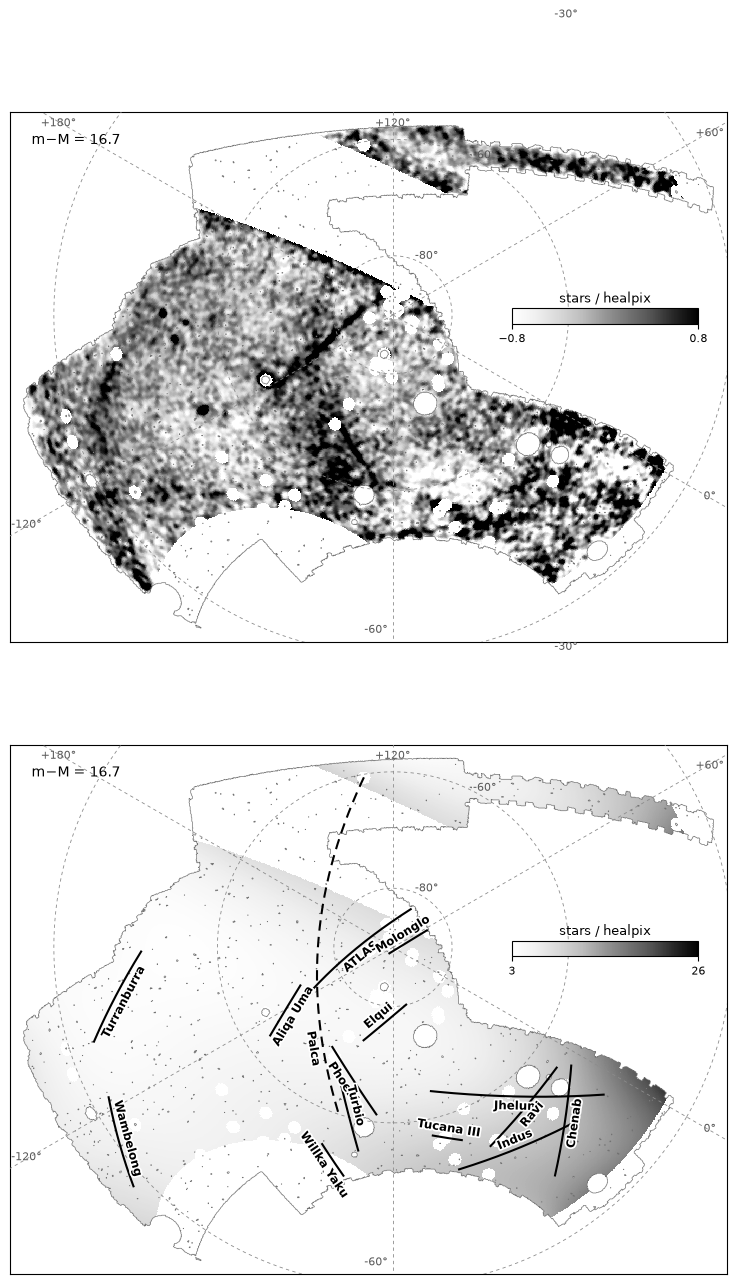

In [12]:
LABEL_SIDE = {"Tucana III": -1, "Indus": -1, "Chenab": -1, "Turbio": -1, "Willka Yaku": 1, "Wambelong": -1,
              "Molonglo": -1, "Elqui": -1, "Ravi": 1, "Jhelum": 1, "Phoenix": 1, "ATLAS": 1, "Aliqa Uma": 1,
              "Turranburra": 1, "Palca": 1}


def galactic_arc(name):
    return (np.atleast_1d(v) for v in TO_GALACTIC(*des2018_arc(name), lonlat=True))


def draw_streams(ax):
    halo = [patheffects.withStroke(linewidth=2.5, foreground="white")]
    for name in DES2018_ENDPOINTS:
        x, y = PROJECTION.ang2xy(*galactic_arc(name), lonlat=True)
        ax.plot(x, y, color="black", lw=1.5, ls=(0, (5, 3)) if name == "Palca" else "-", zorder=4)
        i = len(x) // 2 if name != "Palca" else len(x) // 5
        dx, dy = x[i + 1] - x[i - 1], y[i + 1] - y[i - 1]
        angle = np.degrees(np.arctan2(dy, dx))
        angle = angle - 180 if angle > 90 else angle + 180 if angle < -90 else angle
        nx, ny = -dy / np.hypot(dx, dy), dx / np.hypot(dx, dy)
        offset = 0.028 * LABEL_SIDE[name]
        ax.text(x[i] + offset * nx, y[i] + offset * ny, name, rotation=angle, rotation_mode="anchor",
                ha="center", va="center", fontsize=8.5, fontweight="bold", path_effects=halo, zorder=5)


shown = lambda m: np.where(fitted, m, np.nan)  # the paper blanks the masked sky in both panels
fig, axes = plt.subplots(2, 1, figsize=(8, 12.8))
sky(axes[0], shown(residual["DES 2018"]), -0.8, 0.8, "stars / healpix")
sky(axes[1], shown(model["DES 2018"]), 3.0, 26.0, "stars / healpix")
draw_streams(axes[1])
fig.tight_layout()
plt.show()

## 7. Our selection against DES 2018's

The four selections have different densities, so their residuals are shown in
units of their own counting noise, on one scale. A stream that is darker in
one panel than another is more significant in that selection.

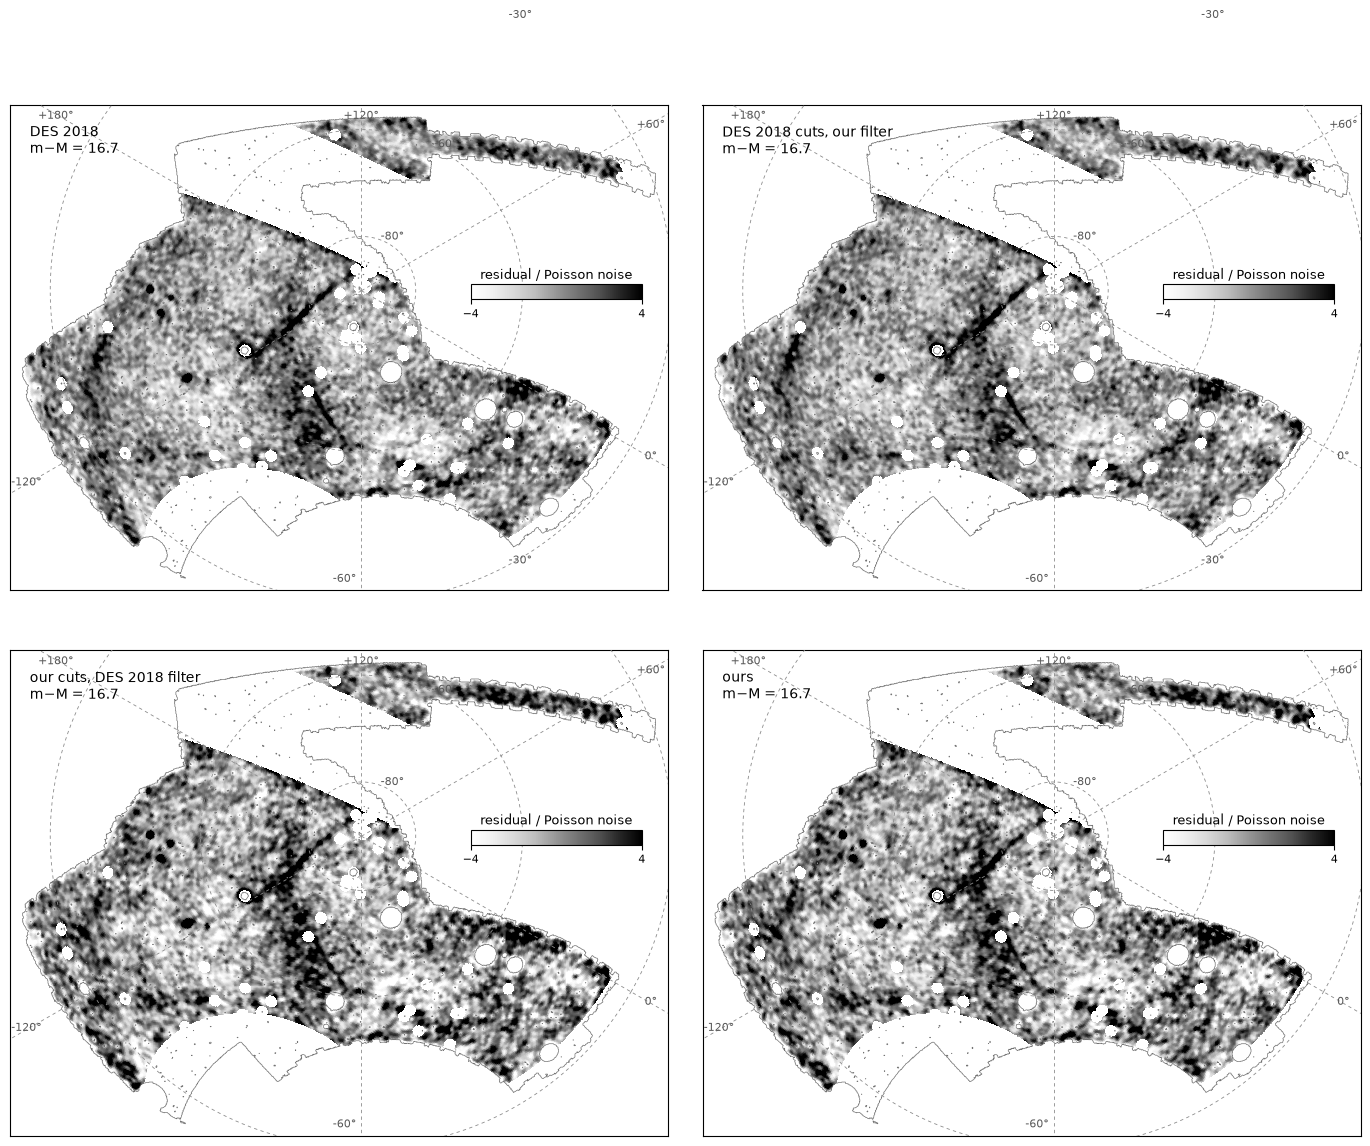

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11.2))
for ax, name in zip(axes.flat, SELECTIONS):
    significance = residual[name] / (np.sqrt(model[name]) * NOISE_FACTOR)
    sky(ax, shown(significance), -4, 4, "residual / Poisson noise", text=f"{name}\nm−M = {DM}")
fig.tight_layout()
plt.show()

## 8. Stream by stream, each at its own distance

m−M = 16.7 suits the streams near it; each stream is now measured at its own
distance modulus (Table 1), in each selection, with the statistic
`scripts/experiments/real_des/run.py` uses for the network's input:

- **band**: pixels within one width (Table 1) of the track;
- **side bands**: pixels two to four widths away, on both sides;
- **S/N** = (stars in the band − expected) / √expected, with the expected
  count from the side bands' mean density.

Pixels within two widths of *another* DES 2018 stream are left out of both,
as are masked and partly covered pixels, so a neighbour — ATLAS beside
Molonglo, or the streams Ravi crosses — cannot pose as background or as
signal. Two tracks per stream: the paper's, and the galstreams one our
real-data detection used (`objects_overlap.DES2018_TRACKS`). The last column
is the paper's own significance (Table 1), from a different, likelihood-based
measurement: it ranks the streams, it is not the same number.

In [14]:
PAPER_SIGNIFICANCE = {"Tucana III": 17.0, "ATLAS": 13.9, "Molonglo": 5.2, "Phoenix": 11.1, "Indus": 21.4,
                      "Jhelum": 18.6, "Ravi": 10.3, "Chenab": 15.1, "Elqui": 18.4, "Aliqa Uma": 9.1,
                      "Turbio": 7.9, "Willka Yaku": 7.1, "Turranburra": 14.4, "Wambelong": 5.9}
STREAMS = list(DES2018_STREAM_WIDTHS)
valid = (coverage == 1) & ~masked
arcs = {name: [tuple(galactic_arc(name))] for name in STREAMS}
galstreams = {name: [tuple(np.atleast_1d(v) for v in TO_GALACTIC(ra, dec, lonlat=True))
                     for ra, dec in stream_tracks(name, tracks=DES2018_TRACKS).values()] for name in STREAMS}
neighbourhood = {name: track_band(arcs[name], 2 * DES2018_STREAM_WIDTHS[name], NSIDE) for name in STREAMS}


def stream_snr(name, tracks, selection):
    """S/N of the stream's band against its side bands, at the stream's own distance."""
    width = DES2018_STREAM_WIDTHS[name]
    others = np.logical_or.reduce([neighbourhood[o] for o in STREAMS if o != name])
    usable = valid & ~others
    band = track_band(tracks, width, NSIDE) & usable
    side = track_band(tracks, 4 * width, NSIDE) & ~track_band(tracks, 2 * width, NSIDE) & usable
    n = np.bincount(pix[select(selection, DES2018_DISTANCE_MODULI[name], (band | side)[pix])], minlength=NPIX)
    expected = n[side].mean() * band.sum()
    return (n[band].sum() - expected) / np.sqrt(expected)


rows = []
for name in STREAMS:
    row = {"stream": name, "m−M": DES2018_DISTANCE_MODULI[name], "width": DES2018_STREAM_WIDTHS[name]}
    row.update({selection: stream_snr(name, arcs[name], selection) for selection in SELECTIONS})
    row["DES 2018, galstreams track"] = stream_snr(name, galstreams[name], "DES 2018")
    row["paper"] = PAPER_SIGNIFICANCE[name]
    rows.append(row)
snr = pd.DataFrame(rows).set_index("stream").sort_values("DES 2018", ascending=False)
snr.round(1)

,m−M,width,DES 2018,"DES 2018 cuts, our filter","our cuts, DES 2018 filter",ours,"DES 2018, galstreams track",paper
stream,,,,,,,,
ATLAS,16.8,0.2,21.6,24.7,19.1,21.5,16.9,13.9
Elqui,18.5,0.5,15.9,18.2,14.5,16.2,14.7,18.4
Phoenix,16.4,0.2,12.2,12.0,12.8,12.9,11.2,11.1
Indus,16.1,0.8,10.3,10.6,10.1,10.3,10.2,21.4
Turranburra,17.2,0.6,10.2,11.1,5.2,5.6,10.3,14.4
Tucana III,17.0,0.2,9.9,11.9,9.3,10.6,9.5,17.0
Aliqa Uma,17.3,0.3,6.5,7.1,5.6,6.6,-1.0,9.1
Chenab,18.0,0.7,6.4,8.2,8.6,10.4,7.3,15.1
Willka Yaku,17.7,0.2,6.2,7.6,8.6,9.7,6.2,7.1


**Each stream, in its own frame.** φ1 runs along the great circle through the
paper's end points and φ2 across it; the dashed brackets sit 1.5° either side
(2.5 widths for the wide streams), as in the paper's Fig. 5. Relative density:
counts smoothed with a Gaussian as wide as the stream (0.1° to 0.5°), over the
same counts smoothed to 1.5°, minus one — so a stream is dark whatever the
density around it. Left of each pair, DES 2018's selection; right, ours.

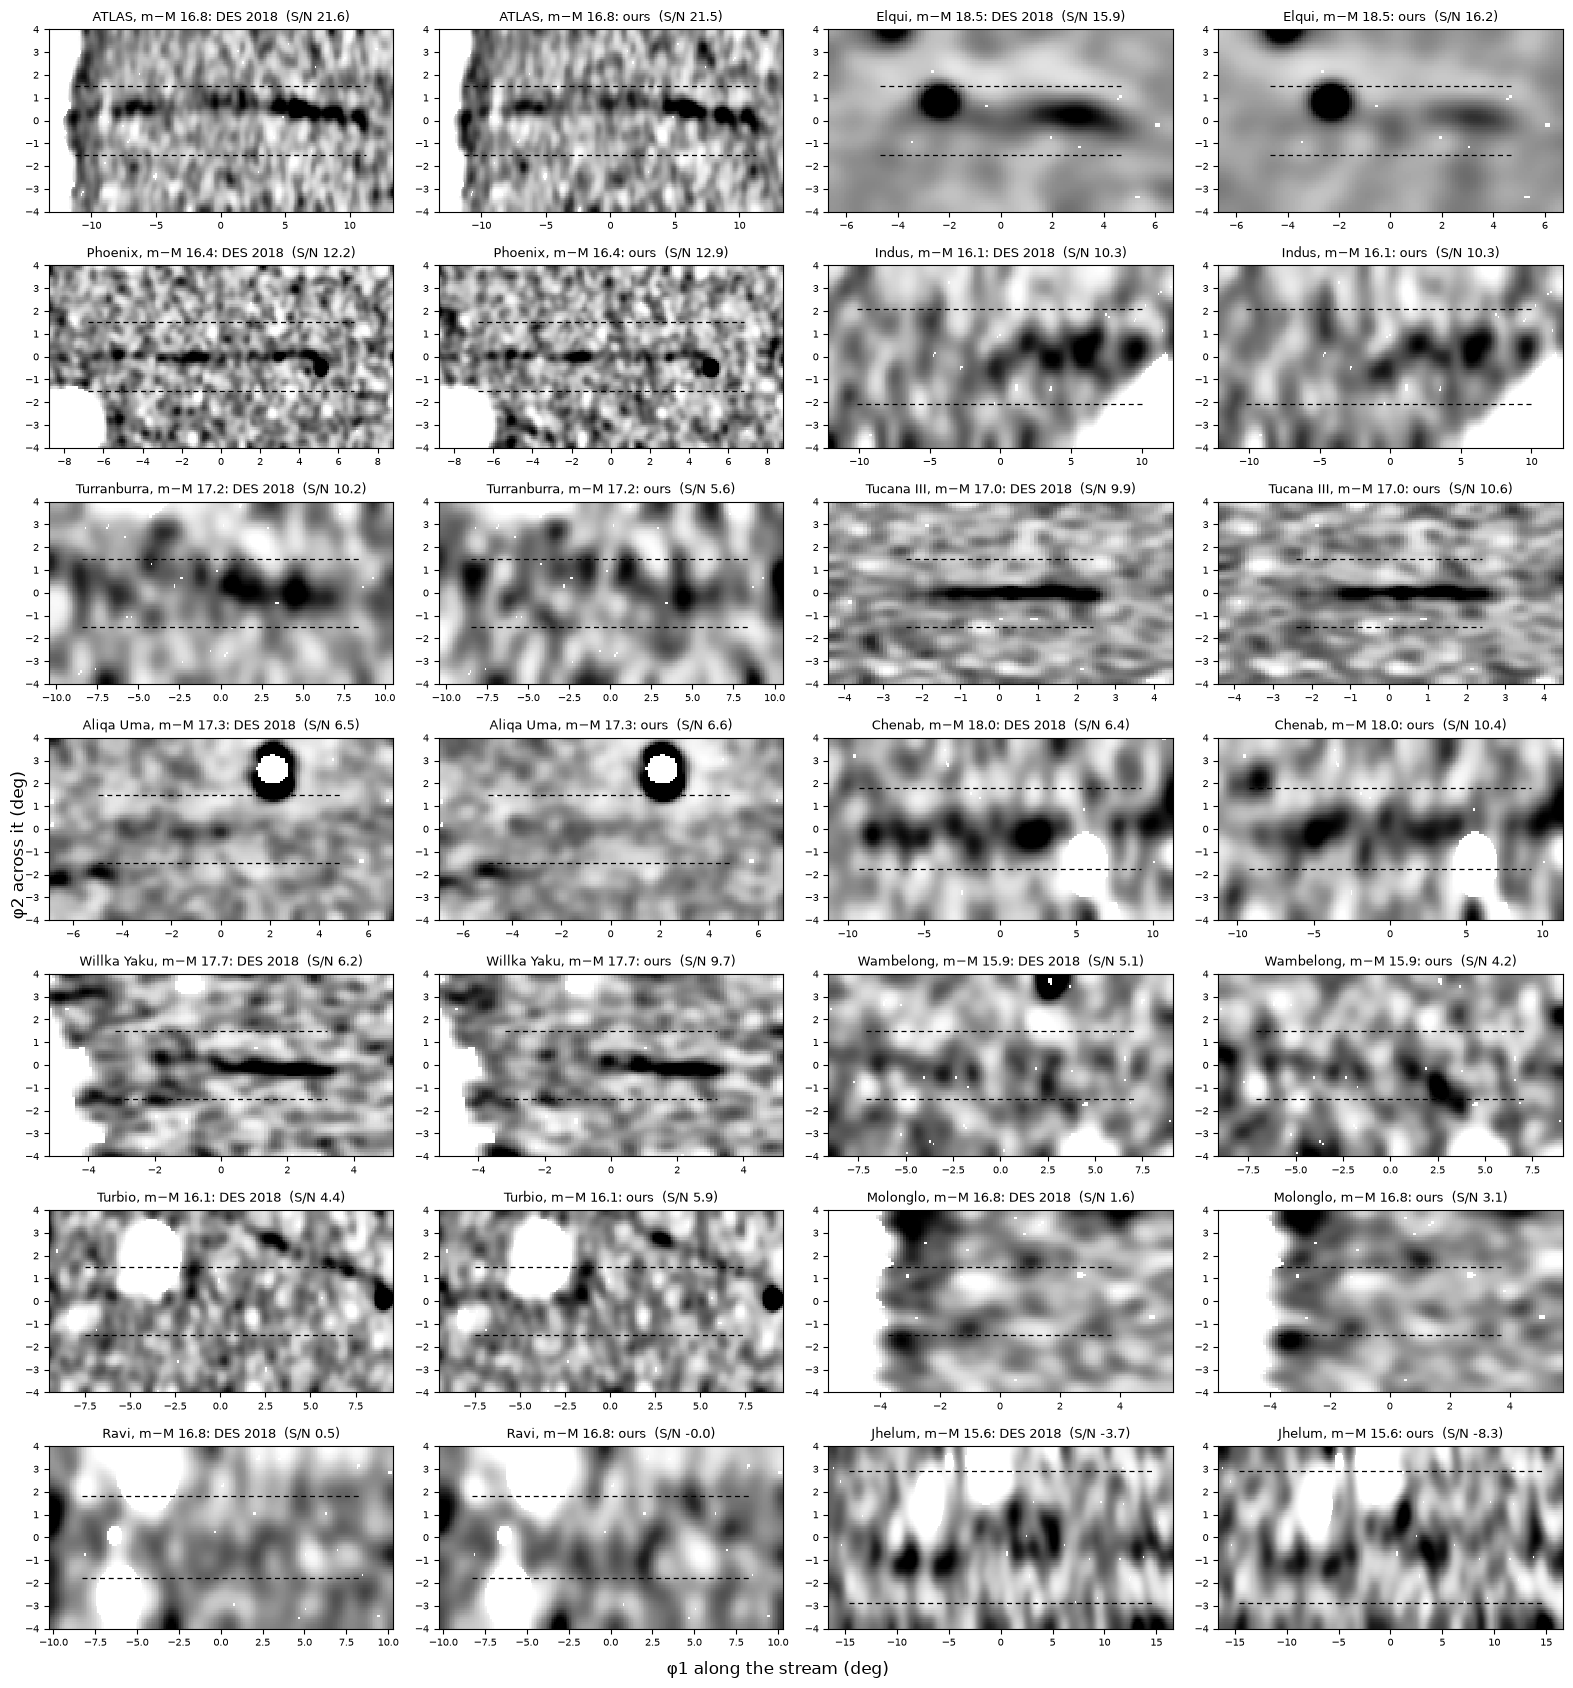

In [15]:
BIN = 0.1  # deg


def stream_frame(name):
    """(middle, along, pole): unit vectors of the great circle through the stream's end points, Galactic."""
    (ra1, dec1), (ra2, dec2) = DES2018_ENDPOINTS[name]
    ends = [hp.ang2vec(*(np.atleast_1d(v)[0] for v in TO_GALACTIC(ra, dec, lonlat=True)), lonlat=True)
            for ra, dec in ((ra1, dec1), (ra2, dec2))]
    pole = np.cross(*ends); pole /= np.linalg.norm(pole)
    middle = ends[0] + ends[1]; middle /= np.linalg.norm(middle)
    return middle, np.cross(pole, middle), pole


def cutout(name, selection, half_length):
    """Relative density in the stream's frame, over phi1 in +-(half_length + 2), phi2 in +-4."""
    middle, along, pole = stream_frame(name)
    region = np.zeros(NPIX, bool)
    region[hp.query_disc(NSIDE, middle, np.radians(half_length + 6))] = True
    rows = region[pix]
    vectors = np.asarray(hp.ang2vec(l[rows], b[rows], lonlat=True))
    phi1 = np.degrees(np.arctan2(vectors @ along, vectors @ middle))
    phi2 = np.degrees(np.arcsin(np.clip(vectors @ pole, -1, 1)))
    edges = (np.arange(-half_length - 2, half_length + 2 + BIN, BIN), np.arange(-4, 4 + BIN, BIN))
    chosen = np.isin(np.flatnonzero(rows), select(selection, DES2018_DISTANCE_MODULI[name], rows))
    n, _, _ = np.histogram2d(phi1[chosen], phi2[chosen], bins=edges)
    covered = (np.histogram2d(phi1, phi2, bins=edges)[0] > 0).astype(float)

    def smoothed_density(sigma_deg):
        return gaussian_filter(n * covered, sigma_deg / BIN) / np.maximum(gaussian_filter(covered, sigma_deg / BIN), 1e-9)

    kernel = np.clip(DES2018_STREAM_WIDTHS[name], 0.1, 0.5)
    relative = smoothed_density(kernel) / smoothed_density(1.5) - 1
    return np.where(covered > 0, relative, np.nan), edges


fig, axes = plt.subplots(7, 4, figsize=(16, 17))
for k, name in enumerate(snr.index):
    half = 0.5 * np.degrees(np.arccos(np.clip(np.dot(*[hp.ang2vec(ra, dec, lonlat=True)
                                                      for ra, dec in DES2018_ENDPOINTS[name]]), -1, 1)))
    bracket = max(1.5, 2.5 * DES2018_STREAM_WIDTHS[name])
    for j, selection in enumerate(("DES 2018", "ours")):
        ax = axes[k // 2, 2 * (k % 2) + j]
        relative, (e1, e2) = cutout(name, selection, half)
        limit = np.nanpercentile(np.abs(relative), 98)
        ax.imshow(relative.T, origin="lower", extent=(e1[0], e1[-1], e2[0], e2[-1]), cmap=GREYS,
                  vmin=-limit, vmax=limit, aspect="auto", interpolation="nearest")
        for side in (-1, 1):
            ax.plot([-half, half], [side * bracket] * 2, color="black", lw=0.9, ls=(0, (4, 3)))
        ax.set_title(f"{name}, m−M {DES2018_DISTANCE_MODULI[name]}: {selection}  (S/N {snr.loc[name, selection]:.1f})",
                     fontsize=9)
        ax.tick_params(labelsize=7)
fig.supxlabel("φ1 along the stream (deg)"); fig.supylabel("φ2 across it (deg)")
fig.tight_layout()
plt.show()